# ProteinMPNN peptide design — analysis of 2P5E chain C

Inverse folding of the **NY-ESO-1 peptide** (chain **C**, native `SLLMWITQC`, HLA-A\*02 9-mer)
designed in the context of the **full complex** (HLA-A\*02 `A`, β2m `B`, TCR `D`+`E` fixed).

This notebook loads the generated sequences and analyses:
1. Load + basic statistics (counts, duplication, score distributions)
2. Per-position residue frequencies & entropy
3. Sequence logos (bits + probability)
4. Comparison vs the native peptide (Hamming identity, per-position recovery, anchors)
5. Amino-acid composition
6. Sequence space (one-hot → PCA / t-SNE / clustering)

Run top-to-bottom. It works on a partial FASTA (while the run is still going) or the final 50K.

In [1]:
# --- Config: all datasets (loads whatever exists; safe to re-run while jobs are still going) ---
from pathlib import Path
ROOT   = Path("/home/ubuntu/if-mhc")
NATIVE = "SLLMWITQC"                                # chain C wild-type
FIGDIR = ROOT / "outputs/analysis/figures"; FIGDIR.mkdir(parents=True, exist_ok=True)

# Full-complex (A+B+D+E context) 50K design — generated in 3 fragments (different seeds)
FC_CANONICAL = ROOT / "outputs/mpnn_50k/seqs/2P5E.fa"          # merged file (exists once Job A completes)
FC_COMPLETE  = ROOT / "outputs/mpnn_50k/COMPLETE"
FC_FRAGMENTS = [ROOT/"outputs/mpnn_50k/seqs/part1.fa",
                ROOT/"outputs/mpnn_50k_part2/seqs/2P5E.fa",
                ROOT/"outputs/mpnn_50k_part3/seqs/2P5E.fa"]
MHCONLY_FASTA = ROOT / "outputs/mpnn_mhconly_v20/seqs/2P5E_ABC.fa"  # MHC-only (A+B) context design
MHCFLURRY_CSV = ROOT / "outputs/mhcflurry/binding_predictions.csv"  # HLA-A*02:01 predictions
SWEEP_FASTA   = ROOT / "outputs/mpnn_tempsweep/seqs/2P5E.fa"        # temperature sweep

# HLA-A*02:01 primary anchors for a 9-mer: P2 and P9 (1-based)
ANCHORS = [2, 9]

In [2]:
import re, itertools, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except Exception:
    display = print
warnings.filterwarnings("ignore")
sns.set_context("notebook"); sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
AA = list("ACDEFGHIKLMNPQRSTVWY")   # 20 canonical
AA_IDX = {a:i for i,a in enumerate(AA)}

## 1. Load sequences

In [3]:
def load_fasta(path):
    """Parse a ProteinMPNN FASTA. The first record (no 'sample=' in header) is the
    native/reference; all others are designs. Works for both 2P5E and 2P5E_ABC files."""
    rows, native = [], None
    p = Path(path)
    if not p.exists():
        return pd.DataFrame(columns=["peptide","score","global_score","seq_recovery","T","sample"]), None
    lines = p.read_text().splitlines()
    for i in range(0, len(lines)-1, 2):
        h, s = lines[i], lines[i+1].strip()
        if not h.startswith(">"):
            continue
        if "sample=" not in h:              # native reference line
            native = s; continue
        d = dict(re.findall(r'(\w+)=([-\d.]+)', h))
        rows.append({"peptide": s,
                     "score": float(d.get("score","nan")),
                     "global_score": float(d.get("global_score","nan")),
                     "seq_recovery": float(d.get("seq_recovery","nan")),
                     "T": float(d.get("T","nan")),
                     "sample": int(float(d.get("sample",0)))})
    return pd.DataFrame(rows), native

def load_many(paths):
    parts, native = [], None
    for p in paths:
        d, n = load_fasta(p)
        if n: native = n
        if len(d): parts.append(d)
    df = pd.concat(parts, ignore_index=True) if parts else \
         pd.DataFrame(columns=["peptide","score","global_score","seq_recovery","T","sample"])
    return df, native

# Full-complex dataset: use the merged file once Job A is COMPLETE, else stitch the live fragments
if FC_COMPLETE.exists() and FC_CANONICAL.exists():
    df, native_in_file = load_fasta(FC_CANONICAL); src = "merged 50K (complete)"
else:
    df, native_in_file = load_many(FC_FRAGMENTS); src = "live fragments (in progress)"
NATIVE = native_in_file or NATIVE
L = len(NATIVE)
df = df[df.peptide.str.len() == L].reset_index(drop=True)
print(f"FULL-COMPLEX designs: {len(df):,}  [{src}] | L={L} | native={NATIVE}")
df.head()

FULL-COMPLEX designs: 50,028  [merged 50K (complete)] | L=9 | native=SLLMWITQC


,peptide,score,global_score,seq_recovery,T,sample
0,MLPNYDTKF,1.1783,1.5336,0.2222,0.3,1
1,MLPNYLTQL,1.1449,1.5473,0.3333,0.3,2
2,MLPNYLTKF,1.0596,1.5511,0.2222,0.3,3
3,MLPNWDTQL,1.1593,1.5493,0.4444,0.3,4
4,MLPNWITRF,1.1829,1.5457,0.4444,0.3,5


### Data inventory — what's loaded this run
Re-run the notebook anytime; each dataset loads whatever has been generated so far.

In [4]:
inv = []
inv.append(("full-complex 50K (A+B+D+E)", len(df), df.peptide.nunique() if len(df) else 0,
            "complete" if FC_COMPLETE.exists() else "in progress"))
_dfm,_ = load_fasta(MHCONLY_FASTA)
inv.append(("MHC-only (A+B)", len(_dfm), _dfm.peptide.nunique() if len(_dfm) else 0,
            "complete" if (ROOT/'outputs/mpnn_mhconly_v20/COMPLETE').exists() else
            ("in progress" if MHCONLY_FASTA.exists() else "not started")))
_sw,_ = load_fasta(SWEEP_FASTA)
inv.append(("temperature sweep", len(_sw), _sw["T"].nunique() if len(_sw) else 0,
            "complete" if (ROOT/'outputs/mpnn_tempsweep/COMPLETE').exists() else
            ("in progress" if SWEEP_FASTA.exists() else "not started")))
nmf = (sum(1 for _ in open(MHCFLURRY_CSV))-1) if MHCFLURRY_CSV.exists() else 0
inv.append(("MHCflurry A*02:01 scored", nmf, nmf, "available" if nmf else "not started"))
inv = pd.DataFrame(inv, columns=["dataset","sequences","unique / #T","status"])
display(inv)

,dataset,sequences,unique / #T,status
0,full-complex 50K (A+B+D+E),50028,3413,complete
1,MHC-only (A+B),50048,10621,complete
2,temperature sweep,20832,7,complete
3,MHCflurry A*02:01 scored,2453,2453,available


In [5]:
# split peptide into per-position columns p1..pL
pos_cols = [f"p{i+1}" for i in range(L)]
df[pos_cols] = df.peptide.apply(lambda s: pd.Series(list(s)))
df.describe(include="all").loc[["count"]].T.head()

,count
peptide,50028
score,50028.0
global_score,50028.0
seq_recovery,50028.0
T,50028.0


## 1b. Basic statistics & duplication

In [6]:
n_total  = len(df)
n_unique = df.peptide.nunique()
print(f"Total sequences : {n_total:,}")
print(f"Unique sequences: {n_unique:,}  ({100*n_unique/n_total:.1f}% unique)")
print(f"Native present  : {'yes' if (df.peptide==NATIVE).any() else 'no'}  "
      f"(recovered {int((df.peptide==NATIVE).sum())}x)")

vc = df.peptide.value_counts()
print("\nTop 10 most frequently sampled designs:")
display(vc.head(10).rename_axis("peptide").reset_index(name="count"))

Total sequences : 50,028
Unique sequences: 3,413  (6.8% unique)
Native present  : no  (recovered 0x)

Top 10 most frequently sampled designs:


,peptide,count
0,MLPNWLTQF,3935
1,MLPNWLTKF,3696
2,MLPNWLTPF,3368
3,MLPNYLTQF,2163
4,MLPNYLTPF,1928
5,MLPNYLTKF,1728
6,MLPNWLTRF,1559
7,MLPNWLTQL,953
8,MLPNWLTKL,949
9,MLPNYLTRF,917


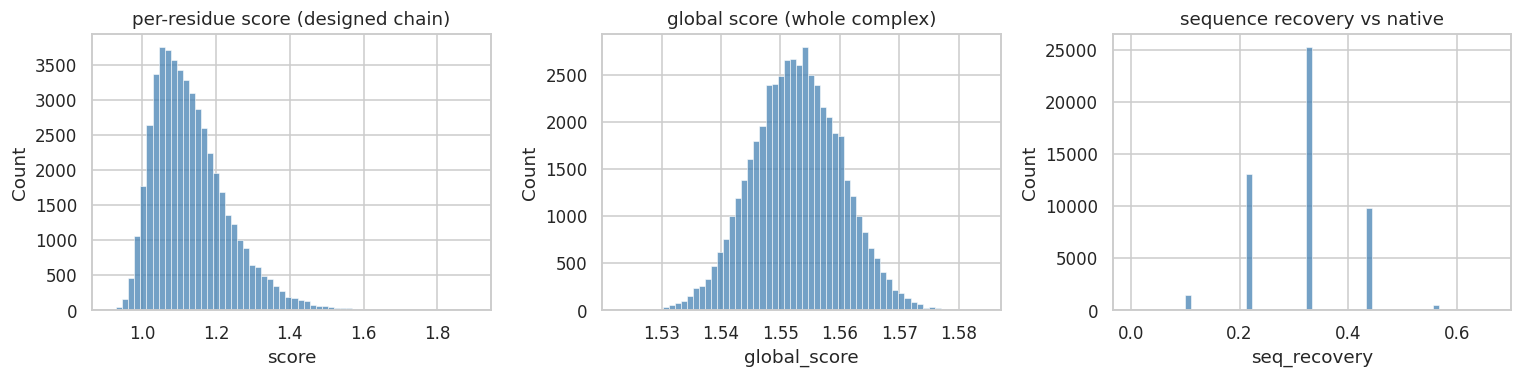

,score,global_score,seq_recovery
count,50028.000000,50028.000000,50028.000000
mean,1.132250,1.552759,0.321369
std,0.100909,0.007470,0.086263
min,0.913200,1.523100,0.000000
25%,1.057300,1.547700,0.222200
50%,1.114900,1.552700,0.333300
75%,1.187125,1.557900,0.333300
max,1.896200,1.584100,0.666700


In [7]:
# score distributions  (lower MPNN score = more probable / better)
fig, ax = plt.subplots(1, 3, figsize=(14,3.6))
for a,(col,title) in zip(ax, [("score","per-residue score (designed chain)"),
                              ("global_score","global score (whole complex)"),
                              ("seq_recovery","sequence recovery vs native")]):
    sns.histplot(df[col].dropna(), bins=60, ax=a, color="steelblue")
    a.set_title(title); a.set_xlabel(col)
plt.tight_layout(); plt.savefig(FIGDIR/"score_distributions.png", bbox_inches="tight"); plt.show()
df[["score","global_score","seq_recovery"]].describe()

## 2. Per-position residue frequencies & entropy

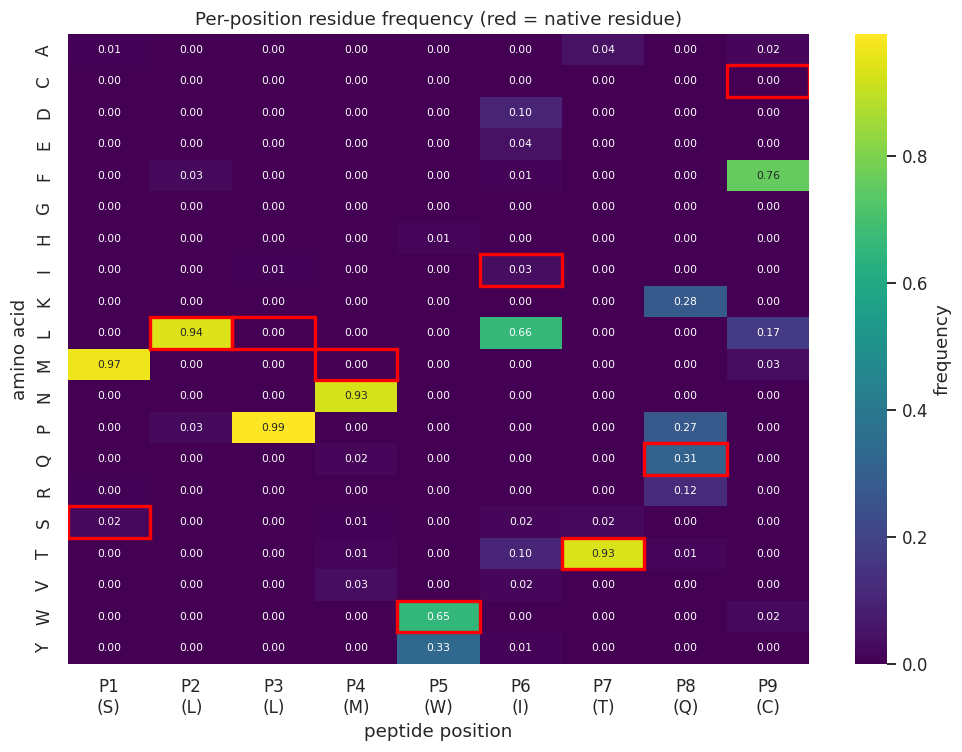

In [8]:
def freq_matrix(seqs, L):
    M = np.zeros((L, len(AA)))
    for s in seqs:
        for i,c in enumerate(s):
            if c in AA_IDX: M[i, AA_IDX[c]] += 1
    M /= M.sum(1, keepdims=True)
    # integer position index (0..L-1) so logomaker accepts it; labels built separately
    return pd.DataFrame(M, columns=AA, index=list(range(L)))

freq = freq_matrix(df.peptide.values, L)        # rows = position (0..L-1), cols = AA
pos_labels = [f"P{i+1}\n({NATIVE[i]})" for i in range(L)]

# transposed orientation: amino acids on Y, peptide positions on X
freqT = freq.T                                   # rows = AA, cols = position
fig, ax = plt.subplots(figsize=(0.7*L+3, 7))
sns.heatmap(freqT, cmap="viridis", annot=True, fmt=".2f", annot_kws={"size":7},
            cbar_kws={"label":"frequency"},
            xticklabels=[f"P{i+1}\n({NATIVE[i]})" for i in range(L)],
            yticklabels=AA, ax=ax)
# mark native residue at each position (now: x=position, y=AA row)
for i,c in enumerate(NATIVE):
    if c in AA_IDX:
        ax.add_patch(plt.Rectangle((i, AA_IDX[c]), 1, 1, fill=False, edgecolor="red", lw=2.2))
ax.set_title("Per-position residue frequency (red = native residue)")
ax.set_xlabel("peptide position"); ax.set_ylabel("amino acid")
plt.tight_layout(); plt.savefig(FIGDIR/"position_frequency_heatmap.png", bbox_inches="tight"); plt.show()

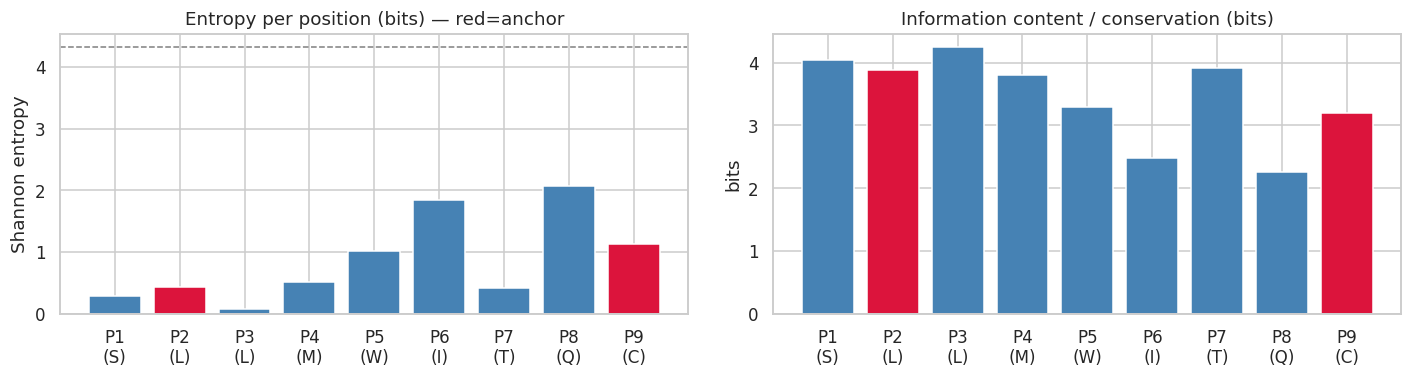

,native,entropy_bits,info_bits
P1,S,0.28,4.04
P2,L,0.43,3.89
P3,L,0.07,4.25
P4,M,0.51,3.81
P5,W,1.02,3.30
P6,I,1.84,2.48
P7,T,0.41,3.91
P8,Q,2.07,2.25
P9,C,1.13,3.19


In [9]:
# Shannon entropy & information content per position
eps = 1e-12
ent = -(freq*np.log2(freq+eps)).sum(1)             # bits, 0..log2(20)=4.32
info = np.log2(len(AA)) - ent                       # conservation (bits)

fig, ax = plt.subplots(1,2, figsize=(13,3.6))
colors = ["crimson" if (i+1) in ANCHORS else "steelblue" for i in range(L)]
ax[0].bar(pos_labels, ent, color=colors); ax[0].set_title("Entropy per position (bits) — red=anchor")
ax[0].set_ylabel("Shannon entropy"); ax[0].axhline(np.log2(20), ls="--", c="grey", lw=1)
ax[1].bar(pos_labels, info, color=colors); ax[1].set_title("Information content / conservation (bits)")
ax[1].set_ylabel("bits")
plt.tight_layout(); plt.savefig(FIGDIR/"per_position_entropy.png", bbox_inches="tight"); plt.show()
pd.DataFrame({"native":list(NATIVE),"entropy_bits":ent.round(2).values,
             "info_bits":info.round(2).values}, index=[f"P{i+1}" for i in range(L)])

## 2c. Per-position residue frequency as a function of temperature

Sampling temperature controls design diversity. Below we load a **temperature-sweep** dataset
(several T values, equal #sequences each) and show the per-position residue frequency
(amino acid on Y, position on X) **faceted by temperature**, plus how per-position entropy and
overall diversity grow with T. Low T → sharp, near-deterministic motif; high T → flatter, more diverse.

In [10]:
# temperature-sweep dataset (multiple T values). Falls back to the main file if not present.
SWEEP_FASTA = ROOT / "outputs/mpnn_tempsweep/seqs/2P5E.fa"
if SWEEP_FASTA.exists():
    dft, _ = load_fasta(SWEEP_FASTA)
    dft = dft[dft.peptide.str.len() == L].reset_index(drop=True)
    print("Loaded temperature sweep:", SWEEP_FASTA)
else:
    dft = df.copy()
    print("No sweep file yet -> using main dataset (single temperature).")
temps = sorted(t for t in dft["T"].dropna().unique())
print("temperatures:", temps)
print("sequences per T:", dft.groupby("T").size().to_dict())

Loaded temperature sweep: /home/ubuntu/if-mhc/outputs/mpnn_tempsweep/seqs/2P5E.fa
temperatures: [np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(1.0)]
sequences per T: {0.1: 2976, 0.15: 2976, 0.2: 2976, 0.3: 2976, 0.5: 2976, 0.7: 2976, 1.0: 2976}


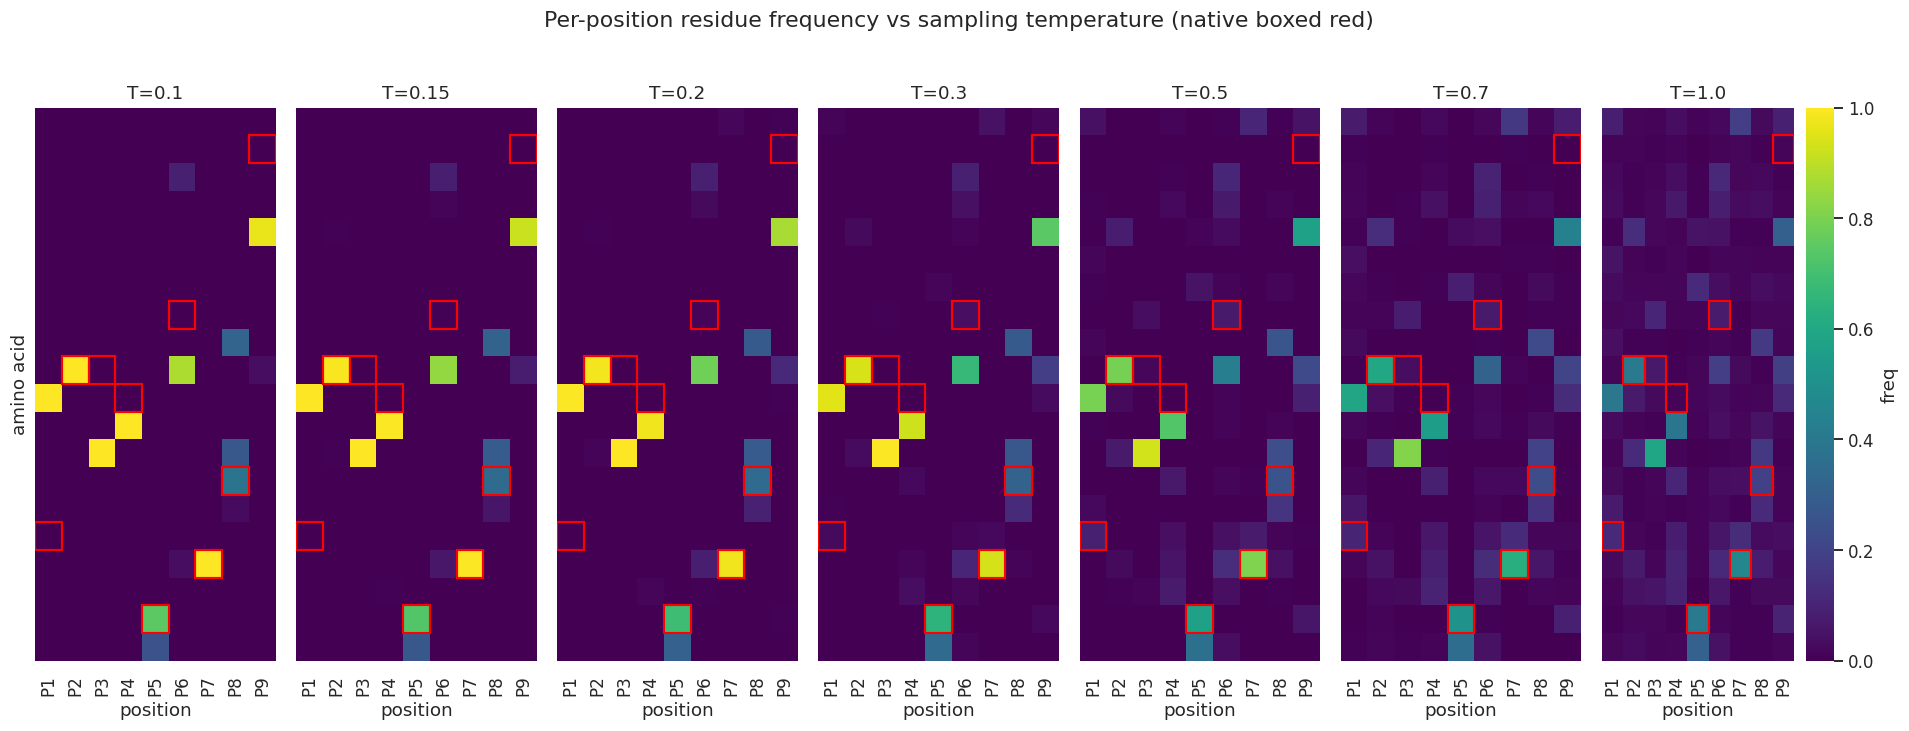

In [11]:
# Faceted heatmaps: residue frequency (AA on Y, position on X), one panel per temperature
ncol = len(temps)
fig, axes = plt.subplots(1, ncol, figsize=(2.3*ncol+1.5, 6.5), sharey=True, squeeze=False)
axes = axes[0]
for ax, T in zip(axes, temps):
    fT = freq_matrix(dft[dft["T"] == T].peptide.values, L).T   # AA x position
    last = (T == temps[-1])
    sns.heatmap(fT, cmap="viridis", vmin=0, vmax=1, ax=ax,
                cbar=last, cbar_kws={"label":"freq"} if last else None,
                xticklabels=[f"P{i+1}" for i in range(L)],
                yticklabels=AA if T == temps[0] else False)
    for i,c in enumerate(NATIVE):
        if c in AA_IDX:
            ax.add_patch(plt.Rectangle((i, AA_IDX[c]),1,1,fill=False,edgecolor="red",lw=1.4))
    ax.set_title(f"T={T}"); ax.set_xlabel("position")
axes[0].set_ylabel("amino acid")
plt.suptitle("Per-position residue frequency vs sampling temperature (native boxed red)", y=1.02)
plt.tight_layout(); plt.savefig(FIGDIR/"freq_vs_temperature.png", bbox_inches="tight"); plt.show()

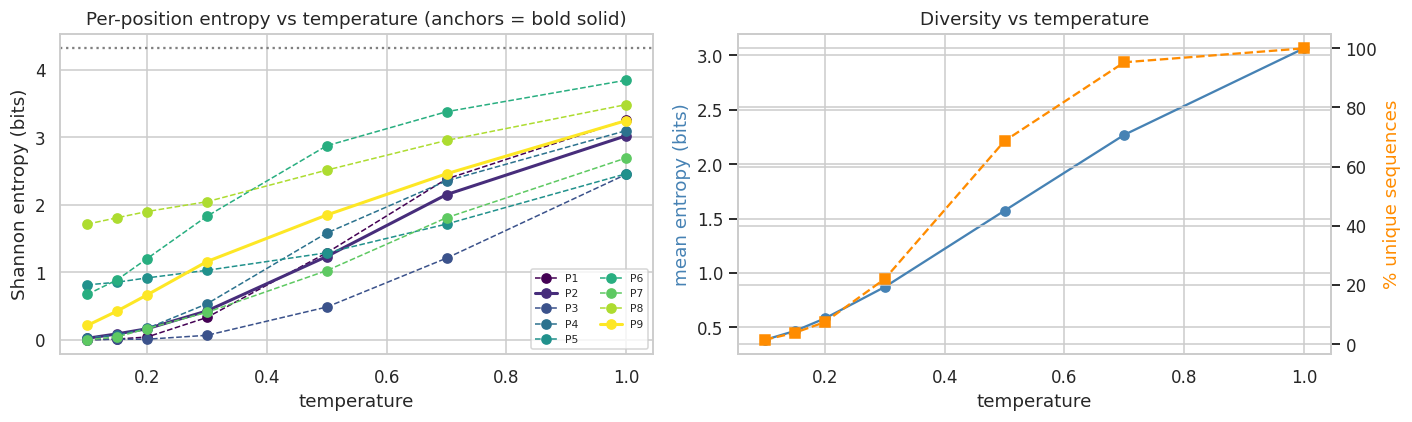

In [12]:
# Per-position entropy vs temperature + overall diversity vs temperature
ent_by_T = {T: -(freq_matrix(dft[dft["T"]==T].peptide.values,L)
                 *np.log2(freq_matrix(dft[dft["T"]==T].peptide.values,L)+eps)).sum(1).values
            for T in temps}
fig, ax = plt.subplots(1, 2, figsize=(13,4))
cmap = plt.cm.viridis(np.linspace(0,1,L))
for i in range(L):
    ax[0].plot(temps, [ent_by_T[T][i] for T in temps], marker="o", color=cmap[i],
               label=f"P{i+1}", lw=2 if (i+1) in ANCHORS else 1,
               ls="-" if (i+1) in ANCHORS else "--")
ax[0].axhline(np.log2(20), ls=":", c="grey"); ax[0].set_xlabel("temperature")
ax[0].set_ylabel("Shannon entropy (bits)")
ax[0].set_title("Per-position entropy vs temperature (anchors = bold solid)")
ax[0].legend(fontsize=7, ncol=2)

mean_ent = [float(np.mean(ent_by_T[T])) for T in temps]
uniq_frac = [dft[dft["T"]==T].peptide.nunique()/max(1,len(dft[dft["T"]==T])) for T in temps]
ax2 = ax[1]; l1=ax2.plot(temps, mean_ent, "o-", c="steelblue", label="mean entropy")
ax2.set_xlabel("temperature"); ax2.set_ylabel("mean entropy (bits)", color="steelblue")
ax3 = ax2.twinx(); l2=ax3.plot(temps, np.array(uniq_frac)*100, "s--", c="darkorange", label="% unique")
ax3.set_ylabel("% unique sequences", color="darkorange")
ax2.set_title("Diversity vs temperature")
plt.tight_layout(); plt.savefig(FIGDIR/"diversity_vs_temperature.png", bbox_inches="tight"); plt.show()

## 3. Sequence logos

Two logos: **information content (bits)** highlights conserved/anchor positions; **probability** shows
the full residue mixture at every position. Native residues annotated underneath.

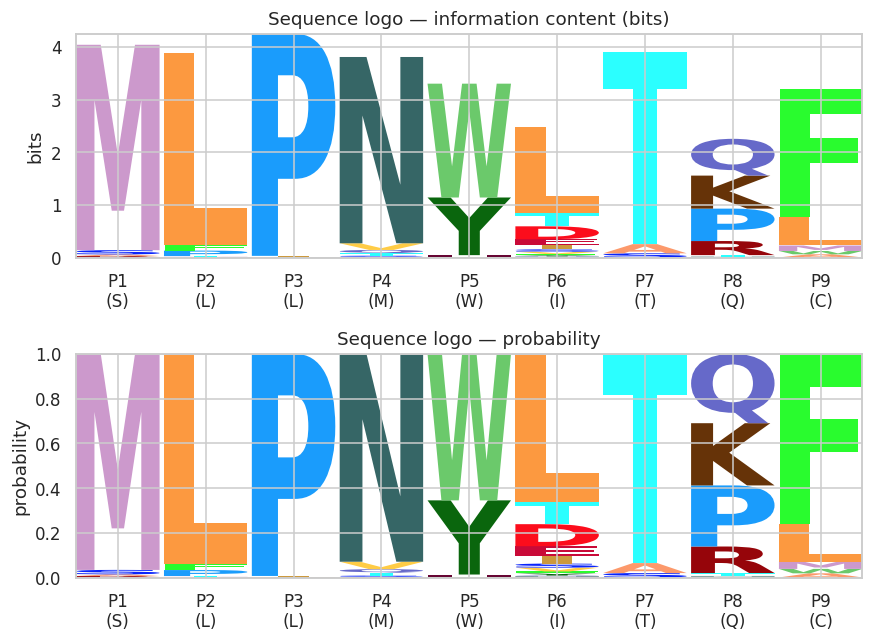

In [13]:
import logomaker
# bits logo
info_mat = logomaker.transform_matrix(freq.copy(), from_type="probability", to_type="information")
fig, axes = plt.subplots(2,1, figsize=(max(6,L*0.9), 6))
lg = logomaker.Logo(info_mat, ax=axes[0], color_scheme="skylign_protein")
axes[0].set_title("Sequence logo — information content (bits)"); axes[0].set_ylabel("bits")
lg2 = logomaker.Logo(freq.copy(), ax=axes[1], color_scheme="skylign_protein", stack_order="big_on_top")
axes[1].set_title("Sequence logo — probability"); axes[1].set_ylabel("probability")
for a in axes:
    a.set_xticks(range(L)); a.set_xticklabels([f"P{i+1}\n({NATIVE[i]})" for i in range(L)])
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_logos.png", bbox_inches="tight"); plt.show()

## 4. Comparison with the native peptide

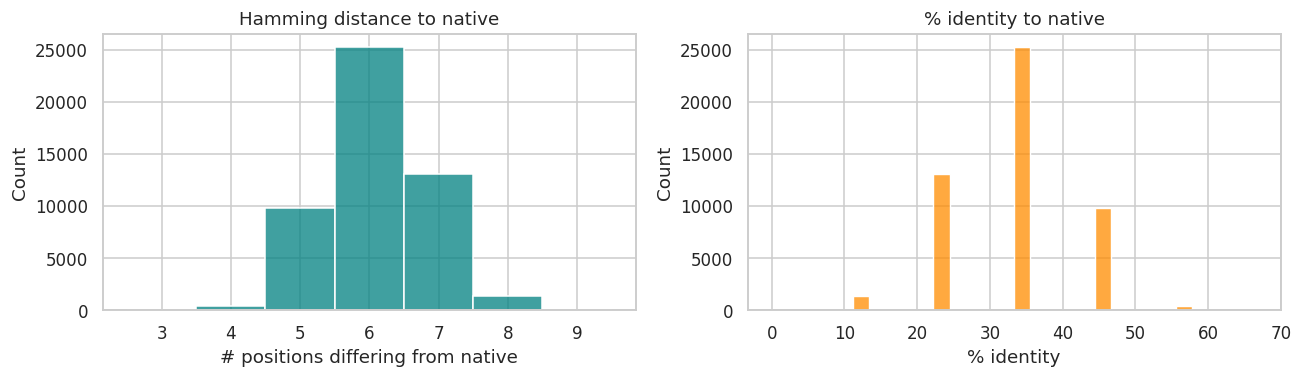

Mean identity to native: 32.1%   mean Hamming: 6.11/9


In [14]:
nat = np.array(list(NATIVE))
P = np.array([list(s) for s in df.peptide.values])
hamming = (P != nat).sum(1)
df["hamming"] = hamming
df["identity"] = 1 - hamming/L

fig, ax = plt.subplots(1,2, figsize=(12,3.6))
sns.histplot(hamming, bins=range(0,L+2), ax=ax[0], color="indseagreen" if False else "teal", discrete=True)
ax[0].set_title("Hamming distance to native"); ax[0].set_xlabel("# positions differing from native")
sns.histplot(df["identity"]*100, bins=30, ax=ax[1], color="darkorange")
ax[1].set_title("% identity to native"); ax[1].set_xlabel("% identity")
plt.tight_layout(); plt.savefig(FIGDIR/"hamming_identity.png", bbox_inches="tight"); plt.show()
print(f"Mean identity to native: {100*df.identity.mean():.1f}%   "
      f"mean Hamming: {hamming.mean():.2f}/{L}")

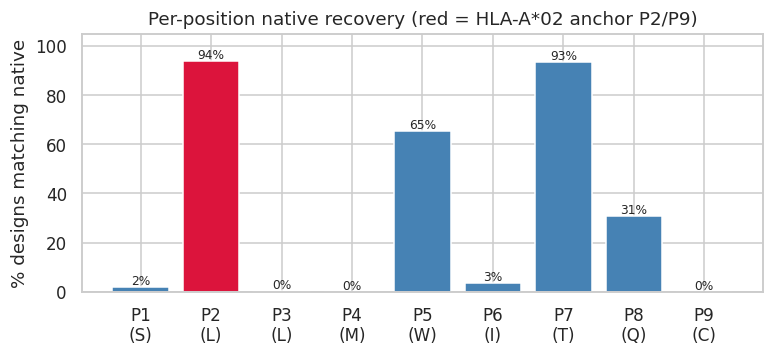

In [15]:
# Per-position recovery: fraction of designs matching native at each position
recovery = (P == nat).mean(0)
fig, ax = plt.subplots(figsize=(max(6,L*0.8),3.4))
colors = ["crimson" if (i+1) in ANCHORS else "steelblue" for i in range(L)]
ax.bar([f"P{i+1}\n({NATIVE[i]})" for i in range(L)], recovery*100, color=colors)
for i,v in enumerate(recovery): ax.text(i, v*100+1, f"{v*100:.0f}%", ha="center", fontsize=8)
ax.set_ylabel("% designs matching native"); ax.set_ylim(0,105)
ax.set_title("Per-position native recovery (red = HLA-A*02 anchor P2/P9)")
plt.tight_layout(); plt.savefig(FIGDIR/"per_position_recovery.png", bbox_inches="tight"); plt.show()

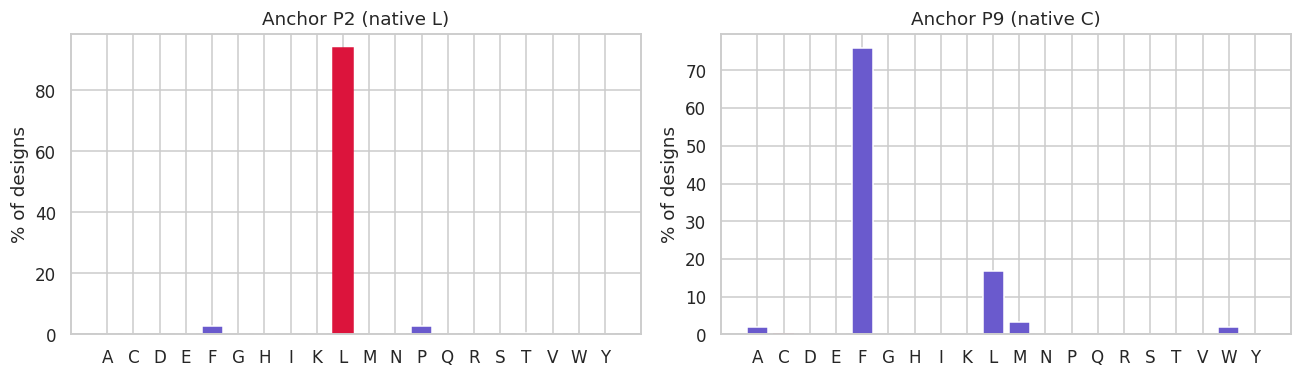

In [16]:
# Anchor residue distributions (P2, P9) — what does MPNN put at the anchors?
fig, ax = plt.subplots(1,len(ANCHORS), figsize=(6*len(ANCHORS),3.6))
if len(ANCHORS)==1: ax=[ax]
for a,p in zip(ax, ANCHORS):
    col = f"p{p}"
    counts = df[col].value_counts(normalize=True).reindex(AA).fillna(0)
    bars = a.bar(AA, counts.values*100, color="slateblue")
    if NATIVE[p-1] in AA_IDX: bars[AA_IDX[NATIVE[p-1]]].set_color("crimson")
    a.set_title(f"Anchor P{p} (native {NATIVE[p-1]})"); a.set_ylabel("% of designs")
plt.tight_layout(); plt.savefig(FIGDIR/"anchor_distributions.png", bbox_inches="tight"); plt.show()

## 5. Amino-acid composition (designs vs native)

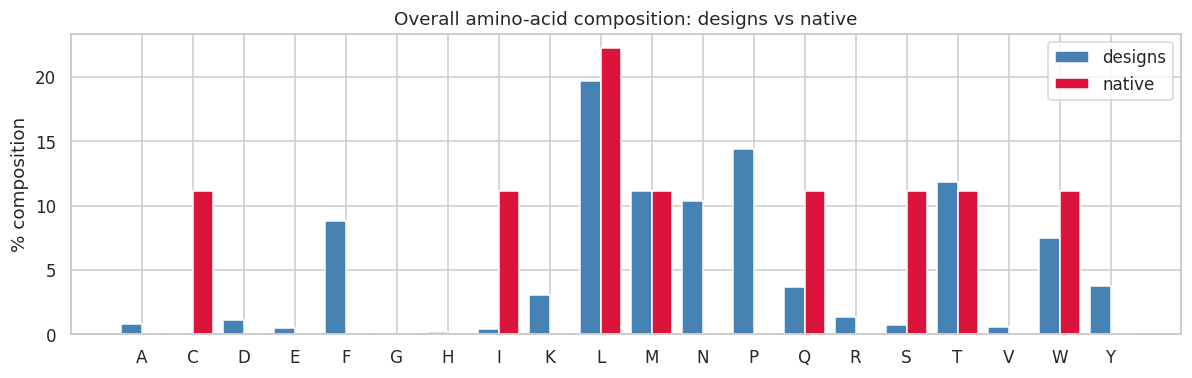

In [17]:
comp = pd.Series(np.concatenate([list(s) for s in df.peptide.values])).value_counts(normalize=True).reindex(AA).fillna(0)
nat_comp = pd.Series(list(NATIVE)).value_counts(normalize=True).reindex(AA).fillna(0)
x = np.arange(len(AA)); w=0.4
fig, ax = plt.subplots(figsize=(11,3.6))
ax.bar(x-w/2, comp.values*100, w, label="designs", color="steelblue")
ax.bar(x+w/2, nat_comp.values*100, w, label="native", color="crimson")
ax.set_xticks(x); ax.set_xticklabels(AA); ax.set_ylabel("% composition"); ax.legend()
ax.set_title("Overall amino-acid composition: designs vs native")
plt.tight_layout(); plt.savefig(FIGDIR/"aa_composition.png", bbox_inches="tight"); plt.show()

## 6. Sequence space

One-hot encode each peptide (`L×20` flattened) and project to 2D with **PCA** (all designs) and
**t-SNE** (subsample). Points coloured by Hamming distance to native and by MPNN score; KMeans clusters shown.

In [18]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def onehot(seqs, L):
    X = np.zeros((len(seqs), L*len(AA)), dtype=np.float32)
    for r,s in enumerate(seqs):
        for i,c in enumerate(s):
            if c in AA_IDX: X[r, i*len(AA)+AA_IDX[c]] = 1
    return X

# de-duplicate for structure analysis (weight each distinct design once)
uniq = df.drop_duplicates("peptide").reset_index(drop=True)
Xu = onehot(uniq.peptide.values, L)
print(f"Unique designs for space analysis: {len(uniq):,}")
pca = PCA(n_components=2, random_state=0).fit(Xu)
uniq[["pc1","pc2"]] = pca.transform(Xu)
print("explained var:", pca.explained_variance_ratio_.round(3))

Unique designs for space analysis: 3,413
explained var: [0.1   0.079]


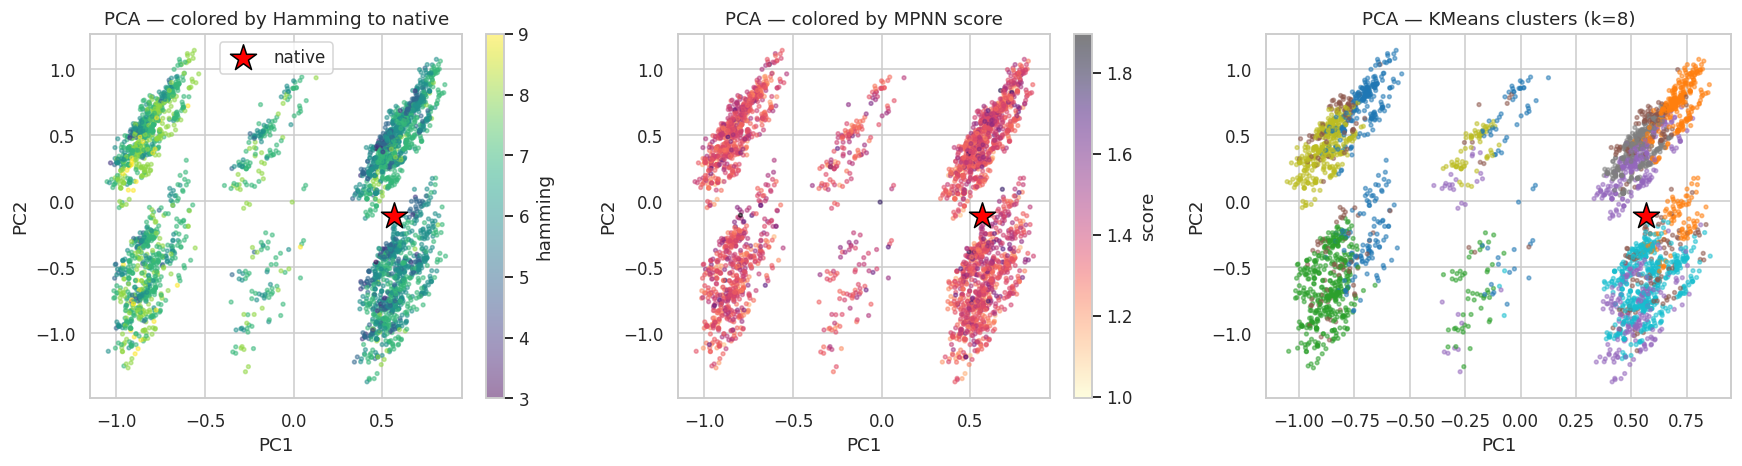

In [19]:
k = min(8, max(2, len(uniq)//50))
uniq["cluster"] = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xu)

fig, ax = plt.subplots(1,3, figsize=(16,4.4))
sc0=ax[0].scatter(uniq.pc1,uniq.pc2,c=uniq.hamming,cmap="viridis",s=6,alpha=.5)
ax[0].set_title("PCA — colored by Hamming to native"); plt.colorbar(sc0,ax=ax[0],label="hamming")
sc1=ax[1].scatter(uniq.pc1,uniq.pc2,c=uniq.score,cmap="magma_r",s=6,alpha=.5)
ax[1].set_title("PCA — colored by MPNN score"); plt.colorbar(sc1,ax=ax[1],label="score")
sc2=ax[2].scatter(uniq.pc1,uniq.pc2,c=uniq.cluster,cmap="tab10",s=6,alpha=.5)
ax[2].set_title(f"PCA — KMeans clusters (k={k})")
# mark native location
nx = pca.transform(onehot([NATIVE],L))[0]
for a in ax: a.scatter(*nx,marker="*",s=320,c="red",edgecolor="k",zorder=5,label="native")
ax[0].legend(loc="best")
for a in ax: a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_space_pca.png", bbox_inches="tight"); plt.show()

UMAP not available in this kernel, showing t-SNE only: ModuleNotFoundError


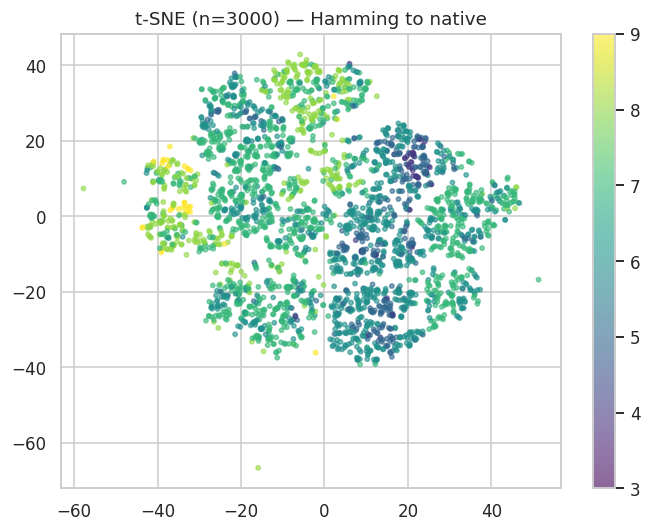

In [20]:
# t-SNE on a subsample (expensive); UMAP if available
from sklearn.manifold import TSNE
n_sub = min(3000, len(uniq))
sub = uniq.sample(n_sub, random_state=0).reset_index(drop=True)
Xs = onehot(sub.peptide.values, L)
emb = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(Xs)
sub[["t1","t2"]] = emb

ncols = 1
try:
    import umap
    um = umap.UMAP(random_state=0).fit_transform(Xs); sub[["u1","u2"]]=um; ncols=2
except Exception as e:
    print("UMAP not available in this kernel, showing t-SNE only:", type(e).__name__)

fig, ax = plt.subplots(1,ncols, figsize=(6.5*ncols,5), squeeze=False)
sc=ax[0][0].scatter(sub.t1,sub.t2,c=sub.hamming,cmap="viridis",s=8,alpha=.6)
ax[0][0].set_title(f"t-SNE (n={n_sub}) — Hamming to native"); plt.colorbar(sc,ax=ax[0][0])
if ncols==2:
    sc2=ax[0][1].scatter(sub.u1,sub.u2,c=sub.hamming,cmap="viridis",s=8,alpha=.6)
    ax[0][1].set_title("UMAP — Hamming to native"); plt.colorbar(sc2,ax=ax[0][1])
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_space_tsne.png", bbox_inches="tight"); plt.show()

## 7. Context comparison — full-complex vs MHC-only

Same peptide, two inverse-folding contexts: designed inside the **full TCR–pMHC complex** (A+B+D+E)
vs the **MHC groove only** (A+B, TCR removed). Differences reveal how much the TCR biases the designs.

MHC-only designs: 50,048   |   full-complex designs: 50,028


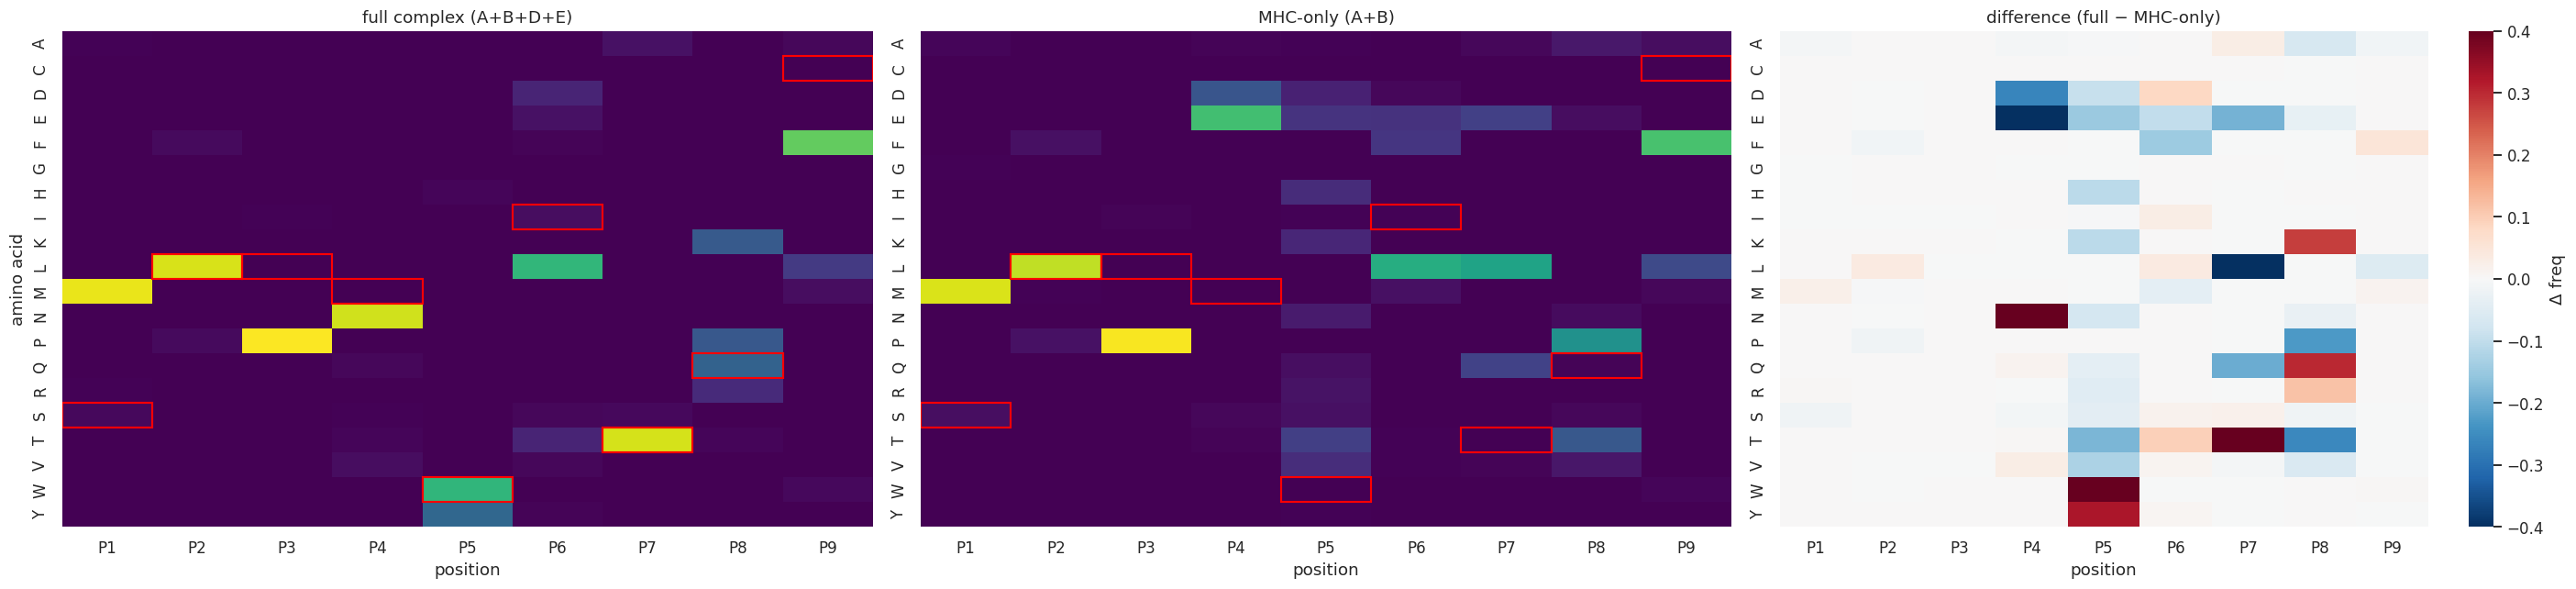

In [21]:
dfm, _ = load_fasta(MHCONLY_FASTA)
dfm = dfm[dfm.peptide.str.len() == L].reset_index(drop=True)
print(f"MHC-only designs: {len(dfm):,}   |   full-complex designs: {len(df):,}")
if len(dfm) == 0:
    print("MHC-only not generated yet — re-run this notebook later to populate this section.")
else:
    fcF = freq_matrix(df.peptide.values, L); moF = freq_matrix(dfm.peptide.values, L)
    fig, ax = plt.subplots(1, 3, figsize=(2.0*L+8, 6))
    for a,(M,t) in zip(ax[:2], [(fcF,"full complex (A+B+D+E)"),(moF,"MHC-only (A+B)")]):
        sns.heatmap(M.T, cmap="viridis", vmin=0, vmax=1, ax=a, cbar=False,
                    xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA)
        for i,c in enumerate(NATIVE):
            if c in AA_IDX: a.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=1.4))
        a.set_title(t); a.set_xlabel("position")
    sns.heatmap((fcF-moF).T, cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4, ax=ax[2],
                xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA, cbar_kws={"label":"Δ freq"})
    ax[2].set_title("difference (full − MHC-only)"); ax[2].set_xlabel("position")
    ax[0].set_ylabel("amino acid")
    plt.tight_layout(); plt.savefig(FIGDIR/"context_freq_comparison.png", bbox_inches="tight"); plt.show()

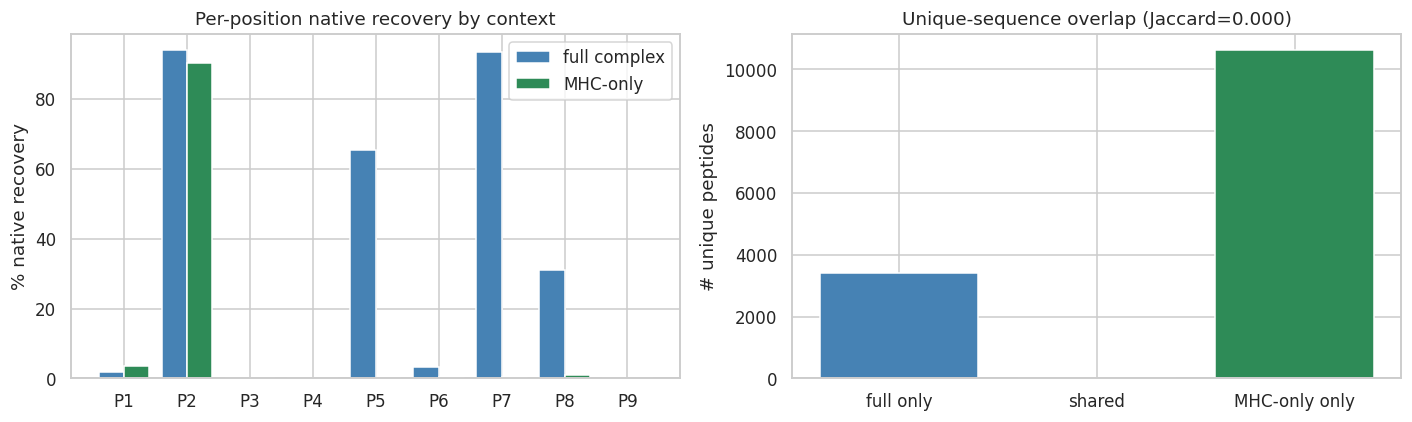

In [22]:
if len(dfm):
    natv = np.array(list(NATIVE))
    recF = (np.array([list(s) for s in df.peptide])  == natv).mean(0)
    recM = (np.array([list(s) for s in dfm.peptide]) == natv).mean(0)
    x = np.arange(L); w = 0.4
    fig, ax = plt.subplots(1, 2, figsize=(13,4))
    ax[0].bar(x-w/2, recF*100, w, label="full complex", color="steelblue")
    ax[0].bar(x+w/2, recM*100, w, label="MHC-only",     color="seagreen")
    ax[0].set_xticks(x); ax[0].set_xticklabels([f"P{i+1}" for i in range(L)])
    ax[0].set_ylabel("% native recovery"); ax[0].legend()
    ax[0].set_title("Per-position native recovery by context")
    sF, sM = set(df.peptide), set(dfm.peptide); inter=len(sF & sM); uni=len(sF | sM)
    ax[1].bar(["full only","shared","MHC-only only"], [len(sF-sM),inter,len(sM-sF)],
              color=["steelblue","grey","seagreen"])
    ax[1].set_title(f"Unique-sequence overlap (Jaccard={inter/max(1,uni):.3f})")
    ax[1].set_ylabel("# unique peptides")
    plt.tight_layout(); plt.savefig(FIGDIR/"context_recovery_overlap.png", bbox_inches="tight"); plt.show()

## 8. HLA-A\*02:01 binding prediction (MHCflurry)

Predicted affinity (nM, lower = stronger) and antigen-presentation score for the designs vs the native
`SLLMWITQC`. The scatter asks whether ProteinMPNN's structural score tracks predicted binding.

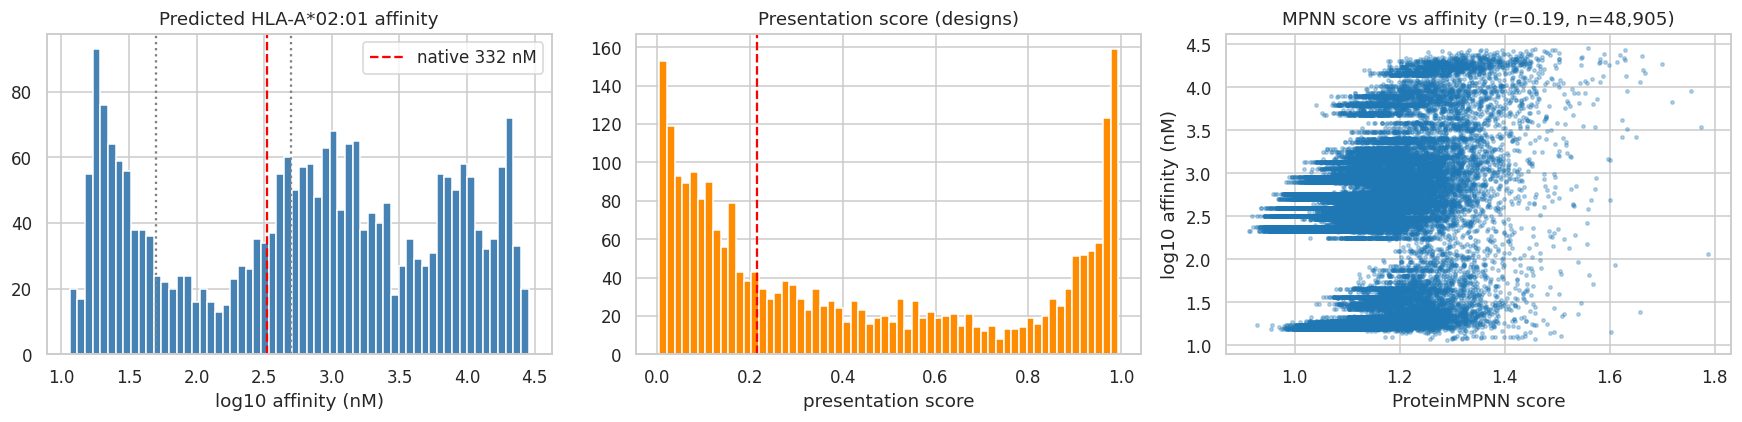

designs scored: 2,452 | strong <50nM: 22.7% | binders <500nM: 42.5% | better than native: 36.2%


,peptide,affinity,presentation_score
795,MLPNWLTQV,11.539942,0.992566
787,MLPNWLTPV,11.664540,0.924886
388,MLINYLTPL,11.901789,0.888674
382,MLINYITQL,11.942417,0.992849
1798,MLVNWLTPL,11.969533,0.890345
377,MLINWTTPL,11.991400,0.945877
404,MLLNWLTPL,11.991946,0.888787
390,MLINYLTQL,12.009241,0.976332
395,MLINYTTPL,12.110719,0.907652
427,MLPDWLTPL,12.329103,0.975266


In [23]:
if not MHCFLURRY_CSV.exists():
    print("MHCflurry predictions not available yet — the binding job writes outputs/mhcflurry/.")
else:
    mf = pd.read_csv(MHCFLURRY_CSV)
    nat = mf[mf.is_native].iloc[0] if ("is_native" in mf and mf.is_native.any()) else None
    des = mf[~mf.is_native] if "is_native" in mf else mf
    fig, ax = plt.subplots(1, 3, figsize=(16,4))
    ax[0].hist(np.log10(des.affinity), bins=60, color="steelblue")
    if nat is not None: ax[0].axvline(np.log10(nat.affinity), color="red", ls="--",
                                      label=f"native {nat.affinity:.0f} nM")
    for thr in (50,500): ax[0].axvline(np.log10(thr), color="grey", ls=":")
    ax[0].set_xlabel("log10 affinity (nM)"); ax[0].set_title("Predicted HLA-A*02:01 affinity"); ax[0].legend()
    ax[1].hist(des.presentation_score, bins=60, color="darkorange")
    if nat is not None: ax[1].axvline(nat.presentation_score, color="red", ls="--")
    ax[1].set_xlabel("presentation score"); ax[1].set_title("Presentation score (designs)")
    mm = df.merge(des[["peptide","affinity"]].drop_duplicates("peptide"), on="peptide", how="inner")
    if len(mm) > 2:
        ax[2].scatter(mm.score, np.log10(mm.affinity), s=5, alpha=.3)
        r = np.corrcoef(mm.score, np.log10(mm.affinity))[0,1]
        ax[2].set_xlabel("ProteinMPNN score"); ax[2].set_ylabel("log10 affinity (nM)")
        ax[2].set_title(f"MPNN score vs affinity (r={r:.2f}, n={len(mm):,})")
    plt.tight_layout(); plt.savefig(FIGDIR/"mhcflurry_binding.png", bbox_inches="tight"); plt.show()
    print(f"designs scored: {len(des):,} | strong <50nM: {(des.affinity<50).mean()*100:.1f}% | "
          f"binders <500nM: {(des.affinity<500).mean()*100:.1f}%"
          + (f" | better than native: {(des.affinity<nat.affinity).mean()*100:.1f}%" if nat is not None else ""))
    display(des.sort_values("affinity")[["peptide","affinity","presentation_score"]].head(15))

## 9. Summary & exports

In [24]:
summary = {
    "total_sequences": int(n_total),
    "unique_sequences": int(n_unique),
    "pct_unique": round(100*n_unique/n_total,2),
    "native": NATIVE,
    "native_recovered_count": int((df.peptide==NATIVE).sum()),
    "mean_identity_to_native_pct": round(100*df.identity.mean(),2),
    "mean_hamming": round(float(hamming.mean()),3),
    "mean_score": round(float(df.score.mean()),4),
    "best_score": round(float(df.score.min()),4),
    "best_design": df.loc[df.score.idxmin(),"peptide"],
}
import json; print(json.dumps(summary, indent=2))

# export: top designs by score, and the per-position frequency table
top = df.sort_values("score").drop_duplicates("peptide").head(100)
top.to_csv(ROOT/"outputs/analysis/top100_by_score.csv", index=False)
freq.to_csv(ROOT/"outputs/analysis/position_frequency.csv")
pd.Series(summary).to_json(ROOT/"outputs/analysis/summary.json")
print("\nTop 10 designs by MPNN score:")
top[["peptide","score","global_score","identity","hamming"]].head(10)

{
  "total_sequences": 50028,
  "unique_sequences": 3413,
  "pct_unique": 6.82,
  "native": "SLLMWITQC",
  "native_recovered_count": 0,
  "mean_identity_to_native_pct": 32.14,
  "mean_hamming": 6.107,
  "mean_score": 1.1323,
  "best_score": 0.9132,
  "best_design": "MLPNWLTQF"
}

Top 10 designs by MPNN score:


,peptide,score,global_score,identity,hamming
44439,MLPNWLTQF,0.9132,1.5352,0.444444,5
33008,MLPNWLTKF,0.9192,1.5589,0.333333,6
10269,MLPNWLTPF,0.9200,1.5613,0.333333,6
31650,MLPNWLTKL,0.9273,1.5506,0.333333,6
48903,MLPNYLTPF,0.9350,1.5521,0.222222,7
3519,MLPNYLTQF,0.9443,1.5536,0.333333,6
35052,MLPNWLTPL,0.9554,1.5761,0.333333,6
37739,MLPNWTTPL,0.9565,1.5335,0.333333,6
30601,MLPNYLTKF,0.9595,1.5700,0.222222,7
12657,MLPNWLTRF,0.9684,1.5617,0.333333,6
